Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 67s 77ms/step - accuracy: 0.9385 - loss: 0.2036 - val_accuracy: 0.9822 - val_loss: 0.0662
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 56s 66ms/step - accuracy: 0.9811 - loss: 0.0607 - val_accuracy: 0.9857 - val_loss: 0.0491
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9868 - loss: 0.0435 - val_accuracy: 0.9873 - val_loss: 0.0513
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 58s 69ms/step - accuracy: 0.9898 - loss: 0.0326 - val_accuracy: 0.9893 - val_loss: 0.0402
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 54s 64ms/step - accuracy: 0.9922 - loss: 0.0246 - val_accuracy: 0.9888 - val_loss: 0.0403

CNN RESULTS
Test Loss: 0.03165628761053085
Test Accuracy: 0.9898999929428101
Precision: 0.9899446074550089
Recall: 0.9899
F1-Score: 0.989904222396485


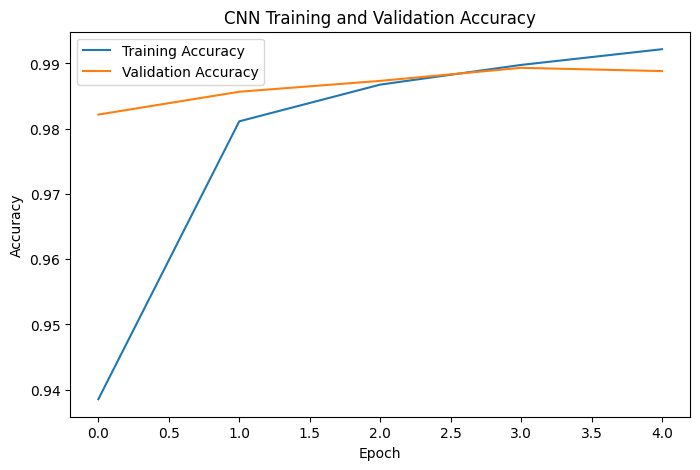

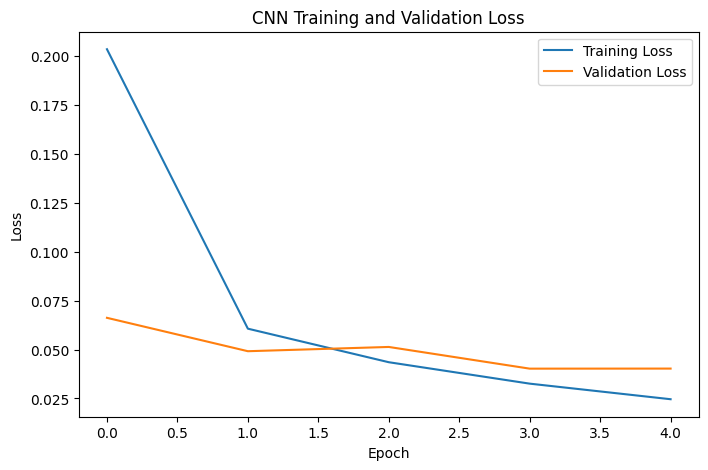

In [2]:
# Experiment No. 10
# Convolutional Neural Network using MNIST Dataset

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# --------------------------------------------------
# Load MNIST Dataset
# --------------------------------------------------

(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


# --------------------------------------------------
# Create CNN Model
# --------------------------------------------------

model = models.Sequential([

    # Convolutional Layer
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    # Pooling Layer
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Layer
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Second Pooling Layer
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into a vector
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(
        64,
        activation="relu"
    ),

    # Output Layer
    layers.Dense(
        10,
        activation="softmax"
    )
])


# --------------------------------------------------
# Compile Model
# --------------------------------------------------

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# --------------------------------------------------
# Train CNN
# --------------------------------------------------

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)


# --------------------------------------------------
# Evaluate Model
# --------------------------------------------------

loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\n======================================")
print("CNN RESULTS")
print("======================================")

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


# --------------------------------------------------
# Predictions
# --------------------------------------------------

y_probability = model.predict(
    X_test,
    verbose=0
)

y_pred = np.argmax(
    y_probability,
    axis=1
)


# --------------------------------------------------
# Calculate Metrics
# --------------------------------------------------

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)


# --------------------------------------------------
# Plot Training Accuracy
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.legend()

plt.show()


# --------------------------------------------------
# Plot Training Loss
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training and Validation Loss")
plt.legend()

plt.show()